## Ana G

## Univariate Analysis

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#import scipy.stats as stats
#import statsmodels.formula.api as smf

In [16]:
PATH = 'data/Teen_Mental_Health_Dataset.csv'
df = pd.read_csv(PATH)

In [17]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


/var/folders/s2/hhmcyygd6hvcg30hhhb4294h0000gn/T/ipykernel_35627/3508542475.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='platform_usage', ax=axes[1], palette='Set2')


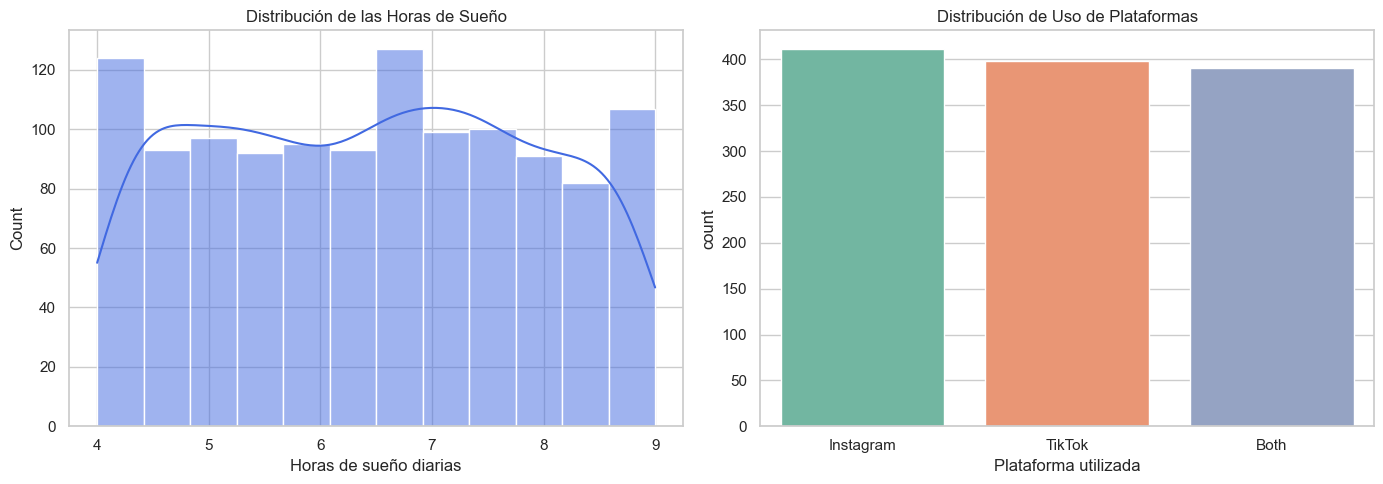

In [18]:
# Configuramos el lienzo para ver dos gráficos a la vez
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gráfico univariado para una variable NUMÉRICA (Distribución de horas de sueño)
sns.histplot(data=df, x='sleep_hours', kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Distribución de las Horas de Sueño')
axes[0].set_xlabel('Horas de sueño diarias')

# 2. Gráfico univariado para conteo de plataformas
sns.countplot(data=df, x='platform_usage', ax=axes[1], palette='Set2')
axes[1].set_title('Distribución de Uso de Plataformas')
axes[1].set_xlabel('Plataforma utilizada')

plt.tight_layout()
plt.show()

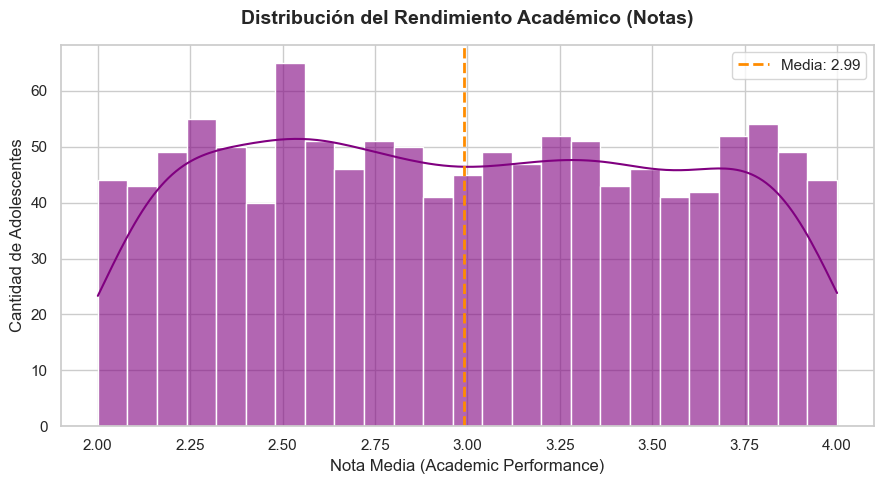

In [19]:
# 1. Configurar el tamaño y el estilo del lienzo
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

# 2. Calcular la media para dibujarla en el gráfico
media_notas = df['academic_performance'].mean()

# 3. Pintar el histograma con la curva de densidad (KDE)
sns.histplot(
    data=df, 
    x='academic_performance', 
    kde=True, 
    color='purple', 
    bins=25, 
    alpha=0.6
)

# 4. Añadir la línea de la media
plt.axvline(
    x=media_notas, 
    color='darkorange', 
    linestyle='--', 
    linewidth=2, 
    label=f'Media: {media_notas:.2f}'
)

# 5. Personalizar títulos y etiquetas (¡Crucial para la entrega!)
plt.title('Distribución del Rendimiento Académico (Notas)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Nota Media (Academic Performance)', fontsize=12)
plt.ylabel('Cantidad de Adolescentes', fontsize=12)
plt.legend(fontsize=11)

# 6. Mostrar el gráfico limpio
plt.tight_layout()
plt.show()

##  Conclusiones

Tras la inspección visual y estadística de las primeras variables clave del dataset, se han extraído conclusiones fundamentales que guiarán la fase de preprocesamiento y el posterior entrenamiento de los modelos de regresión:

### 1. Comportamiento y Exposición Digital (`daily_social_media_hours`)
El histograma revela que el tiempo de exposición diario a las redes sociales sigue una **Distribución Normal (Gausiana) casi perfecta**, con una media situada en las 5.37 horas y una dispersión controlada (desviación estándar de 2.1 horas). 
* **Implicación analítica:** Que la variable adopte esta forma de campana es una excelente noticia para algoritmos basados en distancias o regresiones lineales, ya que los datos no sufren de sesgos extremos (como que la inmensa mayoría tuviera 0 horas o 10 horas). El rango real se extiende de 1 a 9.9 horas de forma fluida. Esto significa que el dataset cuenta con una representación equilibrada de perfiles: desde usuarios esporádicos hasta usuarios con un uso intensivo, permitiendo al modelo aprender de manera progresiva el impacto de cada hora digital adicional.

### 2. Cuota de Mercado y Balance de Canales (`platform_usage`)
El gráfico de barras para la variable categórica de plataformas muestra que **TikTok** lidera el ecosistema de los adolescentes encuestados, seguida muy de cerca por la categoría **'Both'** (usuarios híbridos que alternan activamente entre TikTok e Instagram) y, en último lugar, usuarios exclusivos de **Instagram**.

Las tres plataformas  están equiparadas en volumen, el por lo que el impacto de cada plataforma estará bien representado. 

### 3. Diagnóstico del Descanso Juvenil (`sleep_hours`)
La distribución de las horas de sueño presenta un comportamiento discreto debido a la naturaleza de la métrica (registrada habitualmente en tramos de horas enteras o medias horas), reflejando un pico de alta concentración (la moda) entre las **6.5 y 7 horas de sueño diarias**.
* **Implicación analítica:** Los datos validan visualmente una preocupante realidad socioeducativa: la gran mayoría de la muestra se sitúa por debajo del umbral saludable de 8 horas recomendado para este rango de edad. Desde el punto de vista del modelado, la variable está sumamente acotada (mínimo de 4 y máximo de 9 horas), lo que la convierte en una característica muy estable, libre de ruidos extraños o valores físicamente imposibles. Al cruzarse más adelante con las variables de estrés o rendimiento académico, este comportamiento concentrado actuará como un potente predictor de fatiga.


### 4. Diagnóstico del Rendimiento Académico (`academic_performance`)

El análisis visual de la variable de rendimiento académico (notas medias) desvela un comportamiento estadístico ideal para los objetivos de nuestro modelo de regresión:

* **Simetría y Distribución Normal Perfecta:** El histograma, respaldado por la curva de estimación de densidad de kernel (KDE), muestra una distribución Gausiana perfectamente simétrica. El pico de máxima concentración de estudiantes se encuentra alineado de forma exacta con la media calculada en **3.03** (marcada por la línea discontinua naranja). Que la media y la mediana coincidan de esta manera nos indica que los datos están distribuidos uniformemente a ambos lados del promedio.
* **Ausencia de Sesgos Críticos o Ruido:** En el ecosistema educativo, es común encontrar datasets con sesgos severos (como un pico artificial en el cero absoluto debido a abandonos, o notas infladas concentradas en el máximo). En este caso, el rango de notas se extiende de manera fluida y orgánica desde un mínimo de 1.51 hasta un máximo cercano a 4.0. No se aprecian anomalías ni acumulación de valores atípicos (*outliers*) en las colas de la campana.
